In [5]:
import qiskit
print(qiskit.__version__)

2.4.1


In [22]:
# =========================
# IMPORTS
# =========================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

from models.LSTMAE_pipeline import (
    LSTMAEConfig,
    train_lstm_ae_latent_pipeline,
    plot_training_history,
    plot_reconstructed_series,
    plot_latent_trajectories,
)

In [23]:
# =========================
# LOAD DATA AND SPLIT TRAIN / TEST
# =========================

file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

train_end_idx = 434

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

df_train shape: (434, 17)
df_test shape: (105, 17)


In [24]:
# =========================
# TRAIN LSTM AUTOENCODER
# =========================
# df_train has 434 rows.
# With window_size = 20:
# total train/val windows = 434 - 20 = 414
#
# Use train_window_end = 350:
# X_train = first 350 windows
# X_val   = remaining 64 windows

lstm_config = LSTMAEConfig(
    value_col=4,
    window_size=20,
    latent_dim=6,
    train_window_end=350,
    batch_size=64,
    n_epochs=500,
    learning_rate=0.001,
    dropout_ratio=0.0,
    use_act=False,
    device="cpu",
    save_path="lstm_ae_encoder_checkpoint.pth",
    print_every=10,
)

lstm_results = train_lstm_ae_latent_pipeline(
    df=df_train,
    config=lstm_config,
    fit_scaler_in_train=True,
)

Epoch [10/500] Train Loss: 0.583442 Val Loss: 0.519447
Epoch [20/500] Train Loss: 0.264335 Val Loss: 0.240479
Epoch [30/500] Train Loss: 0.180752 Val Loss: 0.195445
Epoch [40/500] Train Loss: 0.179894 Val Loss: 0.195884
Epoch [50/500] Train Loss: 0.179306 Val Loss: 0.195393
Epoch [60/500] Train Loss: 0.178784 Val Loss: 0.194984
Epoch [70/500] Train Loss: 0.178320 Val Loss: 0.194741
Epoch [80/500] Train Loss: 0.177921 Val Loss: 0.194435
Epoch [90/500] Train Loss: 0.177564 Val Loss: 0.194336
Epoch [100/500] Train Loss: 0.177243 Val Loss: 0.193963
Epoch [110/500] Train Loss: 0.176949 Val Loss: 0.193732
Epoch [120/500] Train Loss: 0.176694 Val Loss: 0.193558
Epoch [130/500] Train Loss: 0.176440 Val Loss: 0.193409
Epoch [140/500] Train Loss: 0.176213 Val Loss: 0.193267
Epoch [150/500] Train Loss: 0.175993 Val Loss: 0.193165
Epoch [160/500] Train Loss: 0.175760 Val Loss: 0.192920
Epoch [170/500] Train Loss: 0.175111 Val Loss: 0.191955
Epoch [180/500] Train Loss: 0.173486 Val Loss: 0.190012
E

In [25]:
# =========================
# CHECK SHAPES
# =========================

print("X_train shape:", lstm_results["X_train"].shape)
print("X_val shape:", lstm_results["X_val"].shape)

print("z_train shape:", lstm_results["z_train"].shape)
print("z_val shape:", lstm_results["z_val"].shape)

print("y_train shape:", lstm_results["y_train"].shape)
print("y_val shape:", lstm_results["y_val"].shape)

X_train shape: (350, 20, 1)
X_val shape: (64, 20, 1)
z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350, 1)
y_val shape: (64, 1)


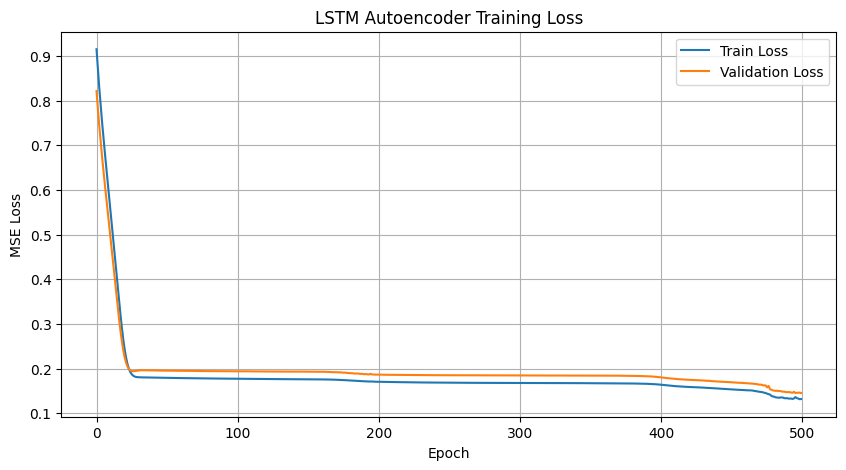

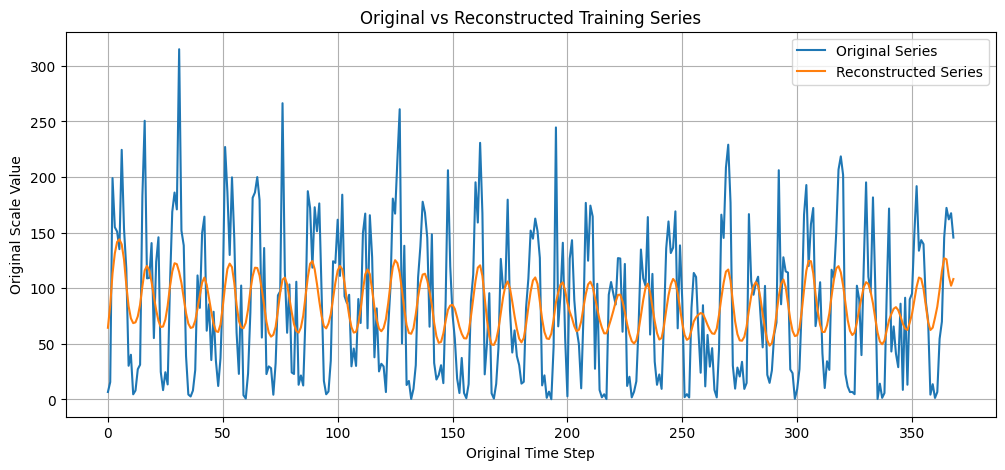

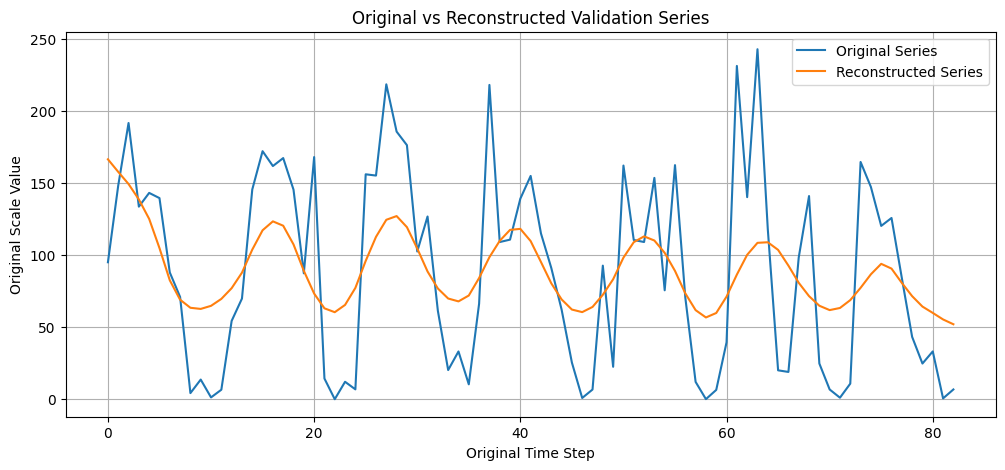

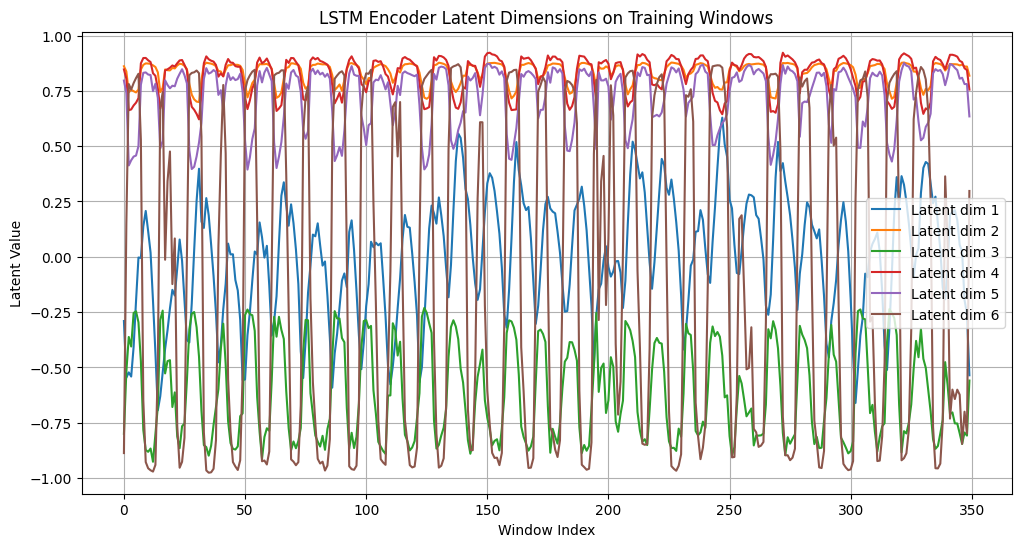

In [26]:
# =========================
# OPTIONAL DIAGNOSTICS
# =========================

plot_training_history(lstm_results["history"])

plot_reconstructed_series(
    original_windows=lstm_results["X_train"],
    reconstructed_windows=lstm_results["X_train_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Training Series",
)

plot_reconstructed_series(
    original_windows=lstm_results["X_val"],
    reconstructed_windows=lstm_results["X_val_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Validation Series",
)

plot_latent_trajectories(
    lstm_results["z_train"],
    title="LSTM Encoder Latent Dimensions on Training Windows",
)

In [27]:
# =========================
# PREPARE QNN DATA FROM LSTM LATENTS
# =========================

z_train = lstm_results["z_train"]
z_val = lstm_results["z_val"]

y_train = lstm_results["y_train"].reshape(-1)
y_val = lstm_results["y_val"].reshape(-1)

print("z_train shape:", z_train.shape)
print("z_val shape:", z_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

# Map LSTM latent vectors to quantum rotation angles.
# z has shape: (num_windows, 6)
# angles will also have shape: (num_windows, 6)
X_qnn_train = np.pi * np.tanh(z_train)
X_qnn_val = np.pi * np.tanh(z_val)

X_qnn_train_torch = torch.tensor(X_qnn_train, dtype=torch.float64)
X_qnn_val_torch = torch.tensor(X_qnn_val, dtype=torch.float64)

y_qnn_train_torch = torch.tensor(y_train, dtype=torch.float64)
y_qnn_val_torch = torch.tensor(y_val, dtype=torch.float64)

print("X_qnn_train_torch:", X_qnn_train_torch.shape)
print("X_qnn_val_torch:", X_qnn_val_torch.shape)
print("y_qnn_train_torch:", y_qnn_train_torch.shape)
print("y_qnn_val_torch:", y_qnn_val_torch.shape)

z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350,)
y_val shape: (64,)
X_qnn_train_torch: torch.Size([350, 6])
X_qnn_val_torch: torch.Size([64, 6])
y_qnn_train_torch: torch.Size([350])
y_qnn_val_torch: torch.Size([64])


In [28]:
# =========================
# QNN DATALOADERS
# =========================

from torch.utils.data import TensorDataset, DataLoader

qnn_batch_size = 32

qnn_train_dataset = TensorDataset(X_qnn_train_torch, y_qnn_train_torch)
qnn_val_dataset = TensorDataset(X_qnn_val_torch, y_qnn_val_torch)

qnn_train_loader = DataLoader(
    qnn_train_dataset,
    batch_size=qnn_batch_size,
    shuffle=True,
)

qnn_val_loader = DataLoader(
    qnn_val_dataset,
    batch_size=qnn_batch_size,
    shuffle=False,
)

In [29]:
# =========================
# QUANTUM CIRCUIT SETUP
# =========================

import pennylane as qml

n_ansatz_layers = 1
n_layers = 5
n_qubits = 6

dev_parallel = qml.device("default.qubit", wires=n_qubits)


def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires=w)


def W(theta):
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(
                theta[l, w, 0],
                theta[l, w, 1],
                theta[l, w, 2],
                wires=w,
            )

        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])

        qml.CNOT(wires=[n_qubits - 1, 0])


@qml.qnode(dev_parallel, interface="torch")
def circuit_parallel(params, x):
    for l in range(n_layers):
        S(x)
        W(params[l])

    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [30]:
# =========================
# HYBRID QNN MODEL
# =========================

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype=torch.float64,
            )
        )

        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 1),
            nn.Tanh(),
        ).double()

    def forward(self, x_batch):
        q_outputs = []

        for x in x_batch:
            q_out = circuit_parallel(self.q_params, x)

            # q_out is a list of n_qubits scalar tensors.
            q_out = torch.stack(q_out)

            q_outputs.append(q_out)

        # Shape: (batch_size, n_qubits)
        q_outputs = torch.stack(q_outputs)

        y_pred = self.classical(q_outputs)

        return y_pred.squeeze(-1)

In [31]:
# =========================
# INITIALIZE QNN MODEL
# =========================

device = torch.device("cpu")

hybrid_model = HybridModel().to(device)

criterion = nn.MSELoss()

# Start smaller than 0.01 if training is unstable.
optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.005)

print(hybrid_model)

HybridModel(
  (classical): Sequential(
    (0): Linear(in_features=6, out_features=1, bias=True)
    (1): Tanh()
  )
)


In [32]:
# =========================
# QNN TRAINING LOOP
# =========================

n_epochs_qnn = 200

train_losses_qnn = []
val_losses_qnn = []

best_val_loss_qnn = float("inf")
best_qnn_state = None

for epoch in range(n_epochs_qnn):
    hybrid_model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in qnn_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = hybrid_model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_train_loss / len(qnn_train_loader.dataset)

    hybrid_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in qnn_val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = hybrid_model(X_batch)

            loss = criterion(y_pred, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = total_val_loss / len(qnn_val_loader.dataset)

    train_losses_qnn.append(avg_train_loss)
    val_losses_qnn.append(avg_val_loss)

    if avg_val_loss < best_val_loss_qnn:
        best_val_loss_qnn = avg_val_loss
        best_qnn_state = copy.deepcopy(hybrid_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{n_epochs_qnn}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

hybrid_model.load_state_dict(best_qnn_state)

print("Best QNN validation loss:", best_val_loss_qnn)

Epoch [10/200] Train Loss: 0.112298 Val Loss: 0.142724
Epoch [20/200] Train Loss: 0.102936 Val Loss: 0.141386
Epoch [30/200] Train Loss: 0.097416 Val Loss: 0.139756
Epoch [40/200] Train Loss: 0.095729 Val Loss: 0.138443
Epoch [50/200] Train Loss: 0.092374 Val Loss: 0.135028
Epoch [60/200] Train Loss: 0.089539 Val Loss: 0.134194
Epoch [70/200] Train Loss: 0.088963 Val Loss: 0.133782
Epoch [80/200] Train Loss: 0.087686 Val Loss: 0.131694
Epoch [90/200] Train Loss: 0.086523 Val Loss: 0.132412
Epoch [100/200] Train Loss: 0.085745 Val Loss: 0.131989
Epoch [110/200] Train Loss: 0.085406 Val Loss: 0.130077
Epoch [120/200] Train Loss: 0.083617 Val Loss: 0.131043
Epoch [130/200] Train Loss: 0.082430 Val Loss: 0.131679
Epoch [140/200] Train Loss: 0.082110 Val Loss: 0.131475
Epoch [150/200] Train Loss: 0.082879 Val Loss: 0.130335
Epoch [160/200] Train Loss: 0.081314 Val Loss: 0.131832
Epoch [170/200] Train Loss: 0.081017 Val Loss: 0.133481
Epoch [180/200] Train Loss: 0.080206 Val Loss: 0.133805
E

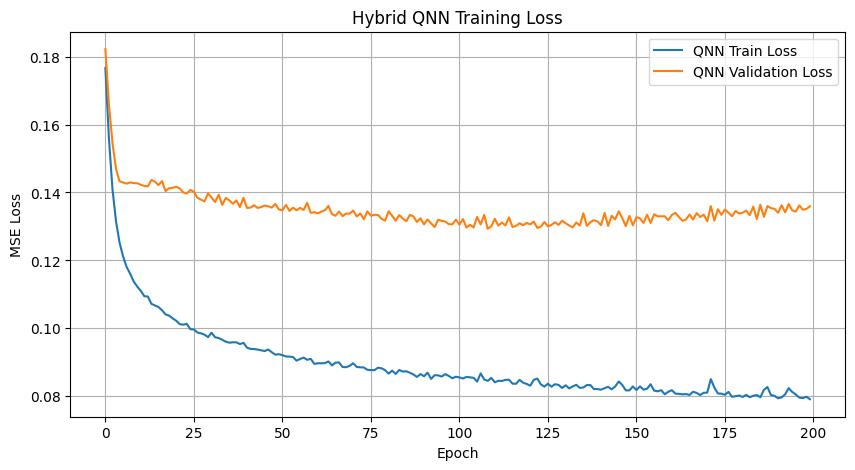

In [33]:
# =========================
# PLOT QNN TRAINING LOSS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(train_losses_qnn, label="QNN Train Loss")
plt.plot(val_losses_qnn, label="QNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Hybrid QNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

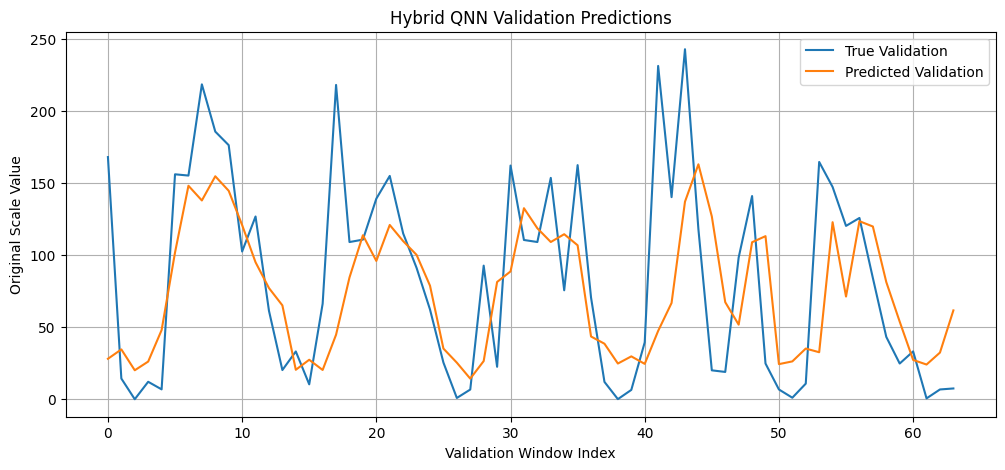

In [34]:
# =========================
# VALIDATION PREDICTIONS
# =========================

hybrid_model.eval()

with torch.no_grad():
    y_pred_val_scaled = hybrid_model(X_qnn_val_torch.to(device)).cpu().numpy()

y_val_scaled = y_qnn_val_torch.cpu().numpy()

scaler = lstm_results["scaler"]

y_pred_val_original = scaler.inverse_transform(
    y_pred_val_scaled.reshape(-1, 1)
).flatten()

y_val_original = scaler.inverse_transform(
    y_val_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 5))
plt.plot(y_val_original, label="True Validation")
plt.plot(y_pred_val_original, label="Predicted Validation")
plt.xlabel("Validation Window Index")
plt.ylabel("Original Scale Value")
plt.title("Hybrid QNN Validation Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# =========================
# VALIDATION METRICS
# =========================

val_mse_scaled = np.mean((y_pred_val_scaled - y_val_scaled) ** 2)
val_rmse_scaled = np.sqrt(val_mse_scaled)

val_mse_original = np.mean((y_pred_val_original - y_val_original) ** 2)
val_rmse_original = np.sqrt(val_mse_original)

val_mae_original = np.mean(np.abs(y_pred_val_original - y_val_original))

print("Validation MSE scaled:", val_mse_scaled)
print("Validation RMSE scaled:", val_rmse_scaled)

print("Validation MSE original:", val_mse_original)
print("Validation RMSE original:", val_rmse_original)
print("Validation MAE original:", val_mae_original)

Validation MSE scaled: 0.1293157349395234
Validation RMSE scaled: 0.35960497068244673
Validation MSE original: 3203.0179805915227
Validation RMSE original: 56.59521164013368
Validation MAE original: 41.89182669910136
